# How the shots get allocated: four real circuits

A minimal, checkable demonstration of what the adaptive method does that Levenberg-Marquardt
does not. Four **real GST circuits** -- gate sequences you can read off the page -- and the two
allocations side by side:

- **LM** splits the budget evenly. Every circuit gets the same number of shots
  (`lm_arms.py`: `per = target_shots / len(circuits)`).
- **adaptive-D** maximises `log det H` over the shot fractions and splits the budget by what
  each circuit actually measures.

The four are picked so the right answer is arguable in advance, so the allocation can be judged
without having to trust the optimiser.

### The mechanism, in one box

Each outcome of each circuit contributes Fisher information

    A_s = sum_beta (grad p_{s,beta})(grad p_{s,beta})^T / p_{s,beta}
    H(rho) = sum_s rho_s A_s          (rho_s = shots on circuit s)

`grad p` is how the outcome probability moves when the model's error parameters move. If a
circuit's probability does not respond to any error, its gradient is zero, it carries no
information, and shots spent on it are wasted. `det H` is zero if any direction goes
unmeasured -- which is what stops the design from piling everything onto the strongest
circuit.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np

SSE = Path.cwd()                                  # run from seed_sweep_experiments
sys.path.insert(0, str(SSE))
sys.path.insert(0, str(SSE.parent))               # GST_POUNDERS, for adaptive_shots

from gst_seed_experiment import ExperimentConfig, GSTProblem, _make_parameterized_model
import adaptive_shots as ashots

N_SHOTS = 100_000
BASELINE_FRAC = 0.001    # token uniform floor, as the real method uses; with no floor at all a
                         # pseudo-determinant can reward a rank-deficient design

t0 = time.time()
cfg = ExperimentConfig.from_json(SSE / "experiment_config.json")
prob = GSTProblem(cfg, 101)
mp = prob.modelpack
prep_fids, meas_fids, germs = mp.prep_fiducials(), mp.meas_fiducials(), mp.germs()

# The Jacobian must be taken at the TRUE parameters, from the converted truth model directly --
# its vector is not interchangeable with base_model's despite having the same length.
truth = _make_parameterized_model(prob.truth_model, cfg.parameterization,
                                  ideal_model=prob.raw_target_model)
print(f"{cfg.modelpack_1q}, {prob.n} model parameters   [{time.time()-t0:.1f}s]")

smq1Q_XYZI, 72 model parameters   [3.7s]


## The four circuits

Every GST circuit is `prep fiducial . germ^L . measurement fiducial`. The germ and its depth
decide which errors get amplified; the fiducials decide which of them are visible at the
measurement.

| | circuit | why it is here |
|---|---|---|
| **A** | `prep_fid[1] . Gxpi2^32 . meas_fid[3]` | a real, deep, informative circuit |
| **B** | `prep_fid[1] . Gxpi2^32 . meas_fid[0]` | **the same 32 gates as A**, read out differently |
| **C** | `prep_fid[1] . Gxpi2^32 . meas_fid[2]` | the same 32 gates, read out on another axis |
| **D** | `prep_fid[0] . idle^4 . meas_fid[0]` | prepare 0, idle, measure Z -- **blind** |

All three of A, B and C run the identical 32-gate sequence and differ only in the measurement
fiducial. That holds the physics fixed and varies only what is visible, which is what makes
them a clean test: any difference in their allocation is about readout, not about the gates.

D is the one whose answer is known in advance. The state is prepared in the 0 state, idles, and
is measured in the Z basis. It never leaves the Z axis, so a Z-type error rotates it about an
axis it already sits on and the outcome probability does not move. D contains error and cannot
see it. Any sensible allocator must refuse to spend on it.

In [2]:
gx = [g for g in germs if len(g) == 1 and "Gxpi2" in str(g)][0]
idle = [g for g in germs if len(g) == 1
        and not any(k in str(g) for k in ("Gxpi2", "Gypi2", "Gzpi2"))][0]

FOUR = [("A   Gxpi2^32 -> meas fid 3", prep_fids[1] + gx * 32 + meas_fids[3]),
        ("B   Gxpi2^32 -> meas fid 0", prep_fids[1] + gx * 32 + meas_fids[0]),
        ("C   Gxpi2^32 -> meas fid 2", prep_fids[1] + gx * 32 + meas_fids[2]),
        ("D   idle^4,  prep 0 meas 0", prep_fids[0] + idle * 4 + meas_fids[0])]
LABELS = [lab for lab, _ in FOUR]
CIRCS = [c for _, c in FOUR]

for lab, c in FOUR:
    print(f"{lab}   (depth {c.depth})")
    print(f"      {c.str}")

A   Gxpi2^32 -> meas fid 3   (depth 35)
      Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0@(0)
B   Gxpi2^32 -> meas fid 0   (depth 33)
      Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0@(0)
C   Gxpi2^32 -> meas fid 2   (depth 34)
      Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gypi2:0@(0)
D   idle^4,  prep 0 meas 0   (depth 4)
      [][][][]@(0)


### The gradients

`|gradient|` is how hard the outcome probability responds to the model's error parameters --
the raw sensitivity of the circuit, and the natural thing to expect shots to follow.

In [3]:
pr = truth.bulk_probabilities(CIRCS)
dp = truth.sim.bulk_dprobs(CIRCS)
J, p, row_circuit = [], [], []
for s, c in enumerate(CIRCS):
    for o in truth.probabilities(c).keys():
        p.append(float(pr[c].get(o, 0.0)))
        J.append(np.asarray(dp[c][o], dtype=float))
        row_circuit.append(s)
J, p, row_circuit = np.array(J), np.array(p), np.array(row_circuit)

grad = {lab: J[row_circuit == i][0] for i, lab in enumerate(LABELS)}

print(f"{'circuit':<30}{'outcome p':>11}{'|gradient|':>14}")
for i, lab in enumerate(LABELS):
    print(f"{lab:<30}{p[row_circuit == i][0]:>11.4f}{np.linalg.norm(grad[lab]):>14.3e}")
print()
print("Three very different strengths: A and B near 2.7e+01, C ten times weaker, D seven orders")
print("of magnitude down. D is not weak, it is blind -- its probability is pinned at 1.0 and")
print("does not move when the error parameters move.")

circuit                         outcome p    |gradient|
A   Gxpi2^32 -> meas fid 3         0.5118     2.712e+01
B   Gxpi2^32 -> meas fid 0         0.4892     2.595e+01
C   Gxpi2^32 -> meas fid 2         0.4948     2.723e+00
D   idle^4,  prep 0 meas 0         0.9995     2.423e-06

Three very different strengths: A and B near 2.7e+01, C ten times weaker, D seven orders
of magnitude down. D is not weak, it is blind -- its probability is pinned at 1.0 and
does not move when the error parameters move.


### How much of that is *new* information

Strength is not what the criterion rewards. What matters is whether a circuit's gradient points
somewhere no other circuit's does, so the cosines are the number to look at.

In [4]:
print("cosine between gradients (1.000 = parallel, i.e. fully redundant)")
print(f"{'':30}" + "".join(f"{l.split()[0]:>9}" for l in LABELS))
for a in LABELS:
    row = ""
    for b in LABELS:
        na, nb = np.linalg.norm(grad[a]), np.linalg.norm(grad[b])
        row += f"{abs(float(grad[a] @ grad[b] / (na * nb))):>9.3f}"
    print(f"{a:<30}{row}")

gA, gB, gC = (grad[LABELS[i]] for i in range(3))
resid = gB - (gA @ gB / (gA @ gA)) * gA
print()
print("Same 32 gates, and yet the readout changes everything:")
print(f"  A vs B   cosine 1.000  -- all but identical")
print(f"  A vs C   cosine {abs(float(gA @ gC / (np.linalg.norm(gA) * np.linalg.norm(gC)))):.3f}  "
      f"-- almost independent, despite the same gates")
print()
print(f"Even A and B are not truly duplicates: B keeps a component orthogonal to A of "
      f"{np.linalg.norm(resid):.3e},")
print(f"which is {100 * np.linalg.norm(resid) / np.linalg.norm(gB):.3f}% of |B|. "
      f"Small -- but not zero, and nothing else covers it.")

cosine between gradients (1.000 = parallel, i.e. fully redundant)
                                      A        B        C        D
A   Gxpi2^32 -> meas fid 3        1.000    1.000    0.132    0.002
B   Gxpi2^32 -> meas fid 0        1.000    1.000    0.133    0.002
C   Gxpi2^32 -> meas fid 2        0.132    0.133    1.000    0.025
D   idle^4,  prep 0 meas 0        0.002    0.002    0.025    1.000

Same 32 gates, and yet the readout changes everything:
  A vs B   cosine 1.000  -- all but identical
  A vs C   cosine 0.132  -- almost independent, despite the same gates

Even A and B are not truly duplicates: B keeps a component orthogonal to A of 1.439e-01,
which is 0.555% of |B|. Small -- but not zero, and nothing else covers it.


## The two allocations

`allocate_shots_per_circuit` is the same function the production runs call. LM's rule is the one
line from `lm_arms.py`.

In [5]:
base = np.full(len(FOUR), BASELINE_FRAC * N_SHOTS / len(FOUR))
extra, _ = ashots.allocate_shots_per_circuit(
    J, p, int((1 - BASELINE_FRAC) * N_SHOTS), row_circuit,
    n_circuit=base, criterion="D", max_iter=3000)
d_share = 100.0 * (base + extra) / N_SHOTS
lm_share = np.full(len(FOUR), 100.0 / len(FOUR))      # per = target_shots / len(circuits)

print(f"{'circuit':<30}{'|gradient|':>13}{'LM':>9}{'adaptive-D':>13}")
for i, lab in enumerate(LABELS):
    print(f"{lab:<30}{np.linalg.norm(grad[lab]):>13.2e}"
          f"{lm_share[i]:>8.1f}%{d_share[i]:>12.1f}%")
print()
print(f"LM spends {lm_share[3]:.0f}% of the budget on a circuit that measures nothing.")
print(f"adaptive-D gives it {d_share[3]:.1f}% and splits the rest evenly over A, B and C.")

circuit                          |gradient|       LM   adaptive-D
A   Gxpi2^32 -> meas fid 3         2.71e+01    25.0%        33.3%
B   Gxpi2^32 -> meas fid 0         2.59e+01    25.0%        33.3%
C   Gxpi2^32 -> meas fid 2         2.72e+00    25.0%        33.3%
D   idle^4,  prep 0 meas 0         2.42e-06    25.0%         0.0%

LM spends 25% of the budget on a circuit that measures nothing.
adaptive-D gives it 0.0% and splits the rest evenly over A, B and C.


### Reading the result

Three things happened, and only the first was obvious in advance.

**D was dropped.** Not for being weak but for being blind -- its gradient is numerically zero,
so no number of shots on it can move `det H`. The allocator got the easy one right.

**C got a full share while being ten times weaker than A.** Its gradient norm is 2.7 against
A's 27, and it is funded identically. Strength bought it nothing; what earned the share is that
its cosine with A and B is 0.13, so it is nearly the only circuit here that can see its
direction. If shots followed sensitivity, C would have received roughly a tenth of A's.

**A and B were *not* thinned, despite being 99.998% redundant.** The tempting prediction is that
a D-optimal design keeps one of a near-duplicate pair. It does not. B still holds a component
A cannot see -- 0.555% of its length -- and `det H` is zero if any direction goes unmeasured, so
a direction covered by exactly one circuit is worth funding no matter how small it is.

That is the rule the method actually follows:

> **Shots follow uniqueness, not strength.** A circuit is funded for the directions only it can
> see, not for how strongly it responds.

The corollary matters when reading the production runs: near-redundant circuits get thinned only
once *another* circuit covers their unique component too. Four circuits against 72 parameters
give no such competition, so only the blind one goes. The full 1918-circuit design has 33
identifiable directions against 1918 circuits, and there the design does become sharply
selective.

### What that buys, in shots

The gain is the ratio of determinants converted to a shot multiplier. `H` is linear in shots, so
`det(cH) = c^r det H`, and `(det H_D / det H_LM)^(1/r)` is the factor by which LM's budget would
have to grow to carry the same information.

Both designs are scored in **one fixed subspace** -- the LM design's identifiable range --
because retained rank otherwise flips near the cutoff and the two determinants stop being
comparable.

In [6]:
def H_of(share):
    w = np.asarray(share, dtype=float)[row_circuit] / np.maximum(p, 1e-9)
    M = (J * w[:, None]).T @ J
    return 0.5 * (M + M.T)

H_lm, H_d = H_of(lm_share), H_of(d_share)
ev, evec = np.linalg.eigh(H_lm)
keep = evec[:, ev > ashots.RANK_CUTOFF * ev.max()]
r = keep.shape[1]

logdet = lambda M: np.linalg.slogdet(keep.T @ M @ keep)[1]
mult = float(np.exp((logdet(H_d) - logdet(H_lm)) / r))

print(f"identifiable rank of this 4-circuit design: {r}   (D contributes none)")
print(f"log det H   LM {logdet(H_lm):.4f}    adaptive-D {logdet(H_d):.4f}")
print()
print(f"shot multiplier: {mult:.4f}x        (4/3 = {4/3:.4f})")
print(f"   adaptive-D at N shots carries the information LM gets from {mult:.2f}N.")
print()
print("It lands exactly on 4/3, which is the right answer and a useful sanity check: with one")
print("of four circuits contributing nothing, moving its 25% onto the three that do is worth")
print("precisely 4/3. On four hand-picked circuits the entire gain IS the waste avoided. On the")
print("full design, where it must also choose among 1918 competing circuits, it is 3.07x.")

identifiable rank of this 4-circuit design: 3   (D contributes none)
log det H   LM 18.5061    adaptive-D 19.3684

shot multiplier: 1.3330x        (4/3 = 1.3333)
   adaptive-D at N shots carries the information LM gets from 1.33N.

It lands exactly on 4/3, which is the right answer and a useful sanity check: with one
of four circuits contributing nothing, moving its 25% onto the three that do is worth
precisely 4/3. On four hand-picked circuits the entire gain IS the waste avoided. On the
full design, where it must also choose among 1918 competing circuits, it is 3.07x.


## The figure

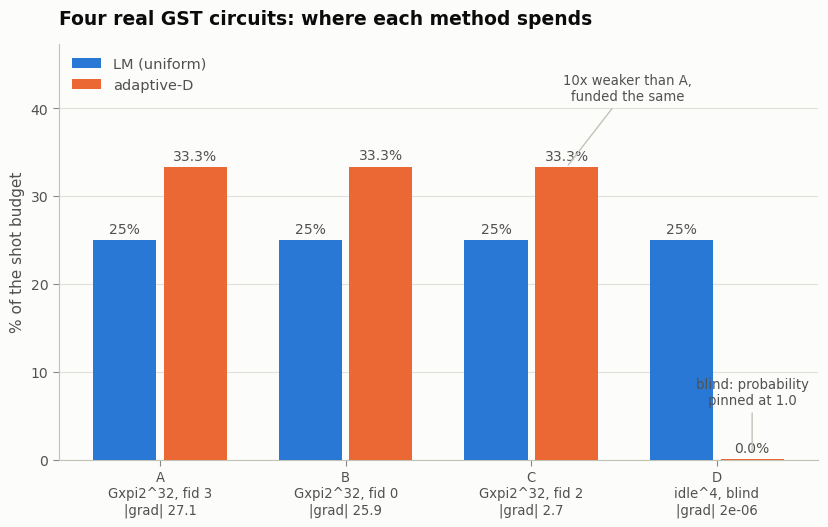

written: C:\Users\athar\Documents\Codex\ANL_SummerInternship\can-you-write-a-code-for\IBCDFO\GST_POUNDERS\seed_sweep_experiments\allocator_demo.png


In [7]:
import matplotlib.pyplot as plt

SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"

fig, ax = plt.subplots(figsize=(9.8, 5.4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.grid(True, axis="y", color=GRID, lw=0.8, zorder=0)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(AXIS)
ax.tick_params(colors=MUTED, labelcolor=INK2, length=4)

x = np.arange(len(FOUR))
ax.bar(x - 0.19, lm_share, width=0.34, color=BLUE, label="LM (uniform)", zorder=3)
ax.bar(x + 0.19, d_share, width=0.34, color=ORANGE, label="adaptive-D", zorder=3)
for xi, (lo, hi) in enumerate(zip(lm_share, d_share)):
    ax.annotate(f"{lo:.0f}%", (xi - 0.19, lo), textcoords="offset points", xytext=(0, 5),
                ha="center", color=INK2, fontsize=10)
    ax.annotate(f"{hi:.1f}%", (xi + 0.19, hi), textcoords="offset points", xytext=(0, 5),
                ha="center", color=INK2, fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels([f"A\nGxpi2^32, fid 3\n|grad| {np.linalg.norm(grad[LABELS[0]]):.1f}",
                    f"B\nGxpi2^32, fid 0\n|grad| {np.linalg.norm(grad[LABELS[1]]):.1f}",
                    f"C\nGxpi2^32, fid 2\n|grad| {np.linalg.norm(grad[LABELS[2]]):.1f}",
                    "D\nidle^4, blind\n|grad| 2e-06"], fontsize=9.5)
ax.set_ylabel("% of the shot budget", color=INK2, fontsize=11)
ax.set_ylim(0, max(d_share.max(), 25) * 1.42)
ax.set_title("Four real GST circuits: where each method spends",
             color=INK, fontsize=13.5, fontweight="semibold", loc="left", pad=14)
ax.annotate("10x weaker than A,\nfunded the same", (2 + 0.19, d_share[2]),
            textcoords="offset points", xytext=(44, 48), ha="center", fontsize=9.5,
            color=INK2, arrowprops=dict(arrowstyle="-", color=AXIS, lw=1))
ax.annotate("blind: probability\npinned at 1.0", (3 + 0.19, 0.6),
            textcoords="offset points", xytext=(0, 36), ha="center", fontsize=9.5,
            color=INK2, arrowprops=dict(arrowstyle="-", color=AXIS, lw=1))
leg = ax.legend(frameon=False, fontsize=10.5, loc="upper left")
for t in leg.get_texts():
    t.set_color(INK2)

fig.savefig(SSE / "allocator_demo.png", dpi=170, bbox_inches="tight", facecolor=SURFACE)
plt.show()
print(f"written: {SSE / 'allocator_demo.png'}")

## Summary

| circuit | gates | `\|gradient\|` | cosine with A | LM | adaptive-D |
|---|---|---|---|---|---|
| **A** | `Gxpi2^32` | 27.1 | 1.000 | 25% | 33.3% |
| **B** | `Gxpi2^32` | 26.0 | 1.000 | 25% | 33.3% |
| **C** | `Gxpi2^32` | 2.7 | 0.132 | 25% | 33.3% |
| **D** | `idle^4` | 2.4e-06 | 0.002 | 25% | **0.0%** |

Same gates in A, B and C; only the readout differs. Shots came out equal across all three
regardless of a 10x spread in sensitivity, and zero on the circuit that cannot see its own
error. The information gain is exactly 4/3 -- the waste LM incurs by funding a blind circuit.

Two things worth carrying forward. **Strength does not buy shots**: C is ten times weaker than A
and funded identically, because it is the only circuit that sees its direction. **Similarity does
not lose them**: A and B are 99.998% parallel and both survive, because D-optimality drops a
circuit only for adding nothing at all, never for adding little. Selectivity in the full design
comes from having far more circuits than identifiable directions, not from pairwise redundancy.